<a href="https://colab.research.google.com/github/moloruns/Olorunsola_DSPN_S26/blob/master/Exercise17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [2]:
library(glmnet)
library(tidyverse)



We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [50]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [51]:
set.seed(121)
train <- sample(1:n, floor(n/2))
test <- (-train)

# train
y.train <- y[train]
x.train <- x[train]
dat.train <- data.frame(X = x.train, Y = y.train)

# test
y.test <- y[test]
x.test <- x[test]
dat.test <- data.frame(X = x.test, Y = y.test)

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

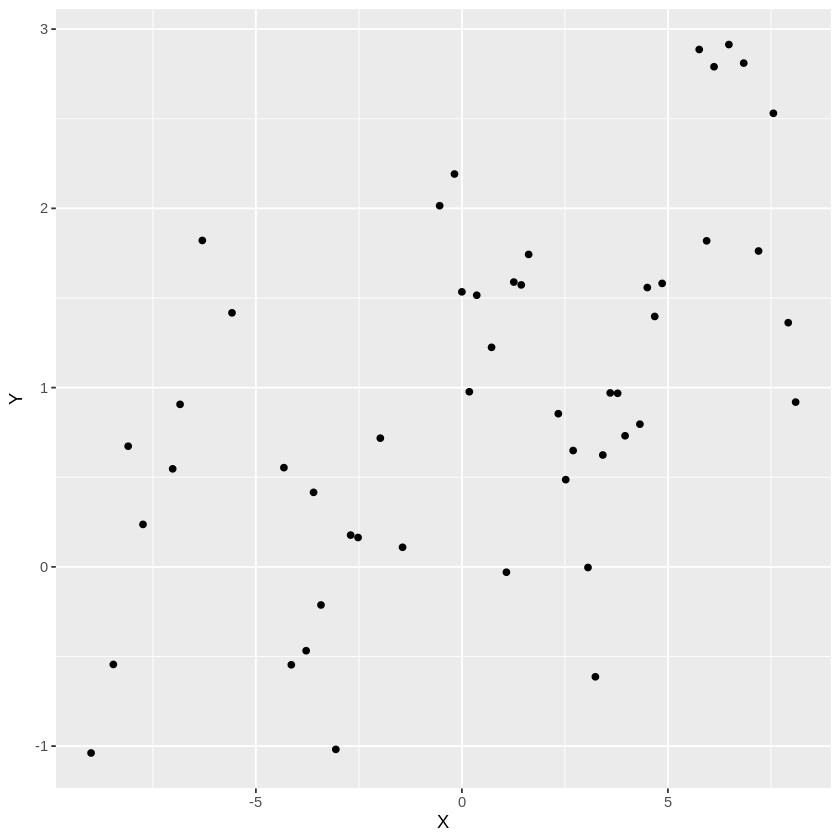

In [52]:
dat.train |>
  ggplot(aes(x = X, y = Y)) +
  geom_point()



How would you describe the relationship between $x$ and $y$ based on this plot?

> We generally observe that as x increases, y seemingly increases as well, suggesting that there is a weak-moderate, positive relationship between the two.
>

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

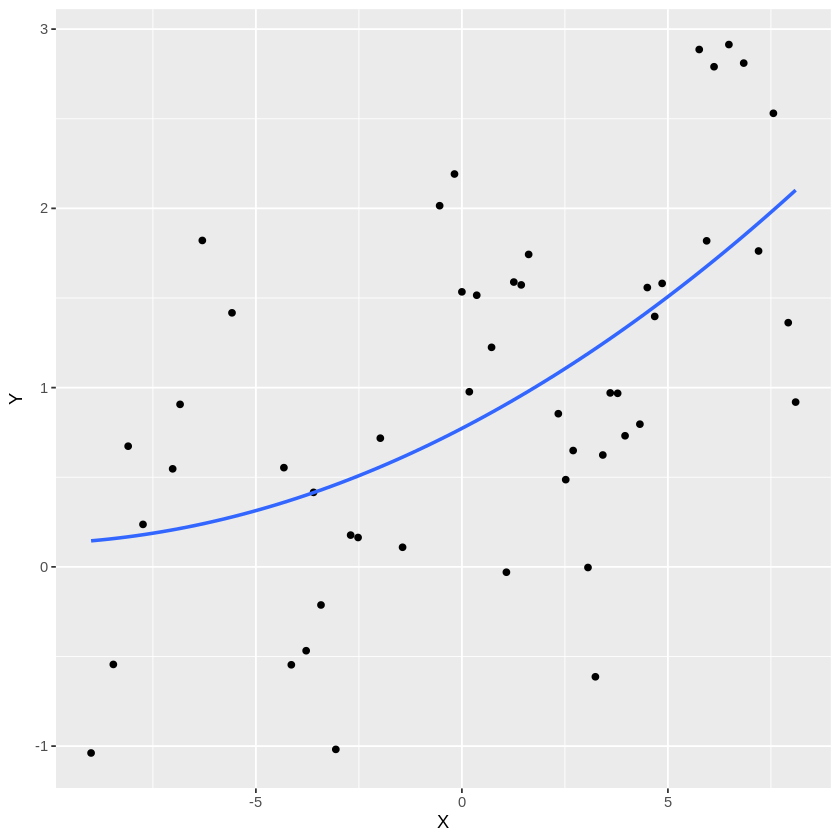

In [53]:
# poly.mod2 <- lm(Y ~ poly(X, 2, raw = TRUE), data = dat.train)

# plot
dat.train |>
  ggplot(aes(x = X, y = Y)) +
  geom_point() +
  stat_smooth(method = "lm", formula = y ~ poly(x, 2, raw = TRUE), se = FALSE)



How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> I'd say the polynomial model does a decent job at fitting the data, given that it generally captures the overall trend of the training data; yes it could do better.
>

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

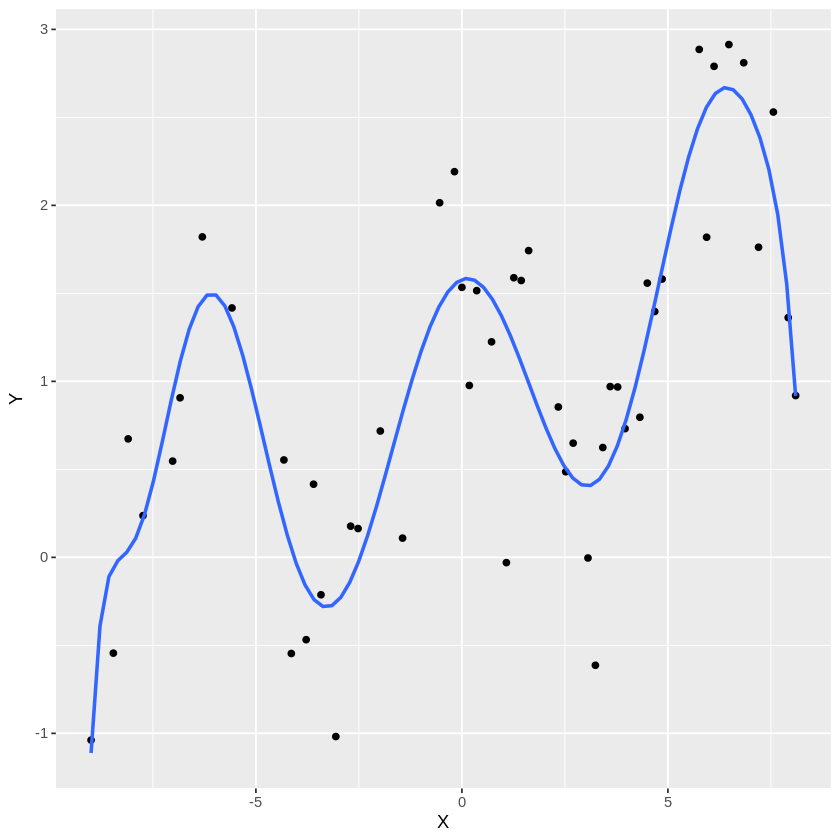

In [54]:
# poly.mod12 <- lm(Y ~ poly(X, 12, raw = TRUE), data = dat.train)

# plot
dat.train |>
  ggplot(aes(x = X, y = Y)) +
  geom_point() +
  stat_smooth(method = "lm", formula = y ~ poly(x, 12, raw = TRUE), se = FALSE)



> Worse
>

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in pred

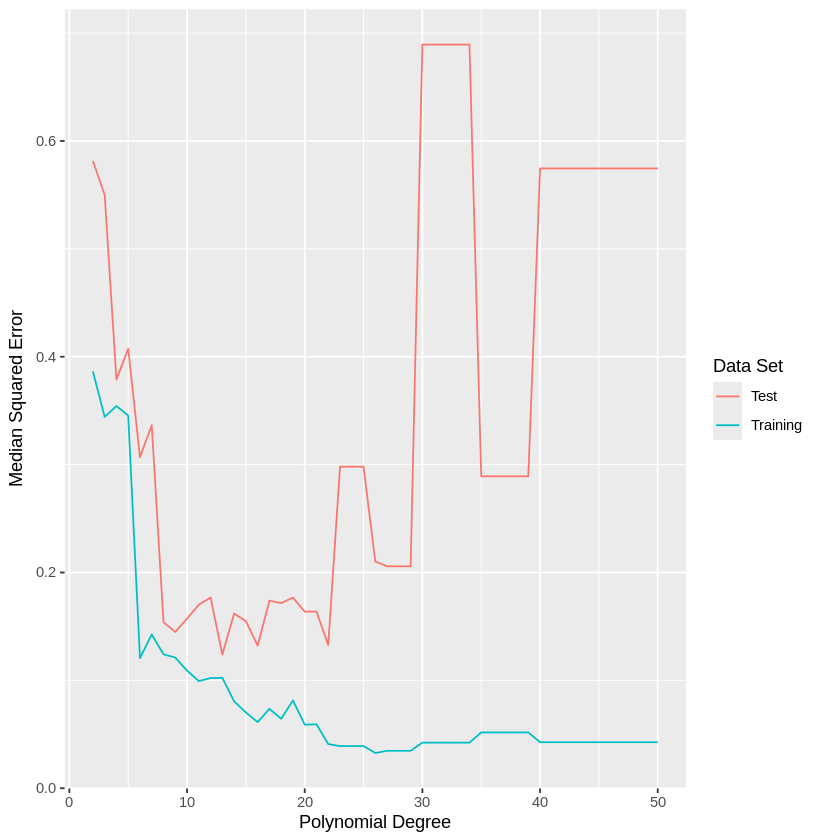

In [70]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    poly.mod <- lm(Y ~ poly(X, k, raw = TRUE), data = dat.train)

    # predict
    train.pred <- predict(poly.mod, newdata = dat.train)
    # squared error
    train.error <- (dat.train$Y - train.pred)^2
    # store rss
    train_rss[k-1] <- median(train.error)

    # test predict
    test.pred <- predict(poly.mod, newdata = dat.test)
    # squared error
    test.error <- (dat.test$Y - test.pred)^2
    # store test rss
    test_rss[k-1] <- median(test.error)
}

results <- data.frame(
    degree = rep(degree, 2),
    rss = c(train_rss, test_rss),
    type = rep(c("Training", "Test"), each = length(degree))
)

# Plot your results here
results |>
  ggplot(aes(x = degree, y = rss, color = type)) +
  geom_line() +
  labs(x = "Polynomial Degree",
       y = "Median Squared Error",
       color = "Data Set")


What do you see as $k$ increase?

> As k increases from 2 to about 15, both training and test error decrease. However as k continues to increase beyond this optimal range, training error continues to decrease (and approach zero) due to overfitting, while test error begins to increase dramatically after a certain point (for k > 20).
>

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly.mod, newdata = dat.train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in pred

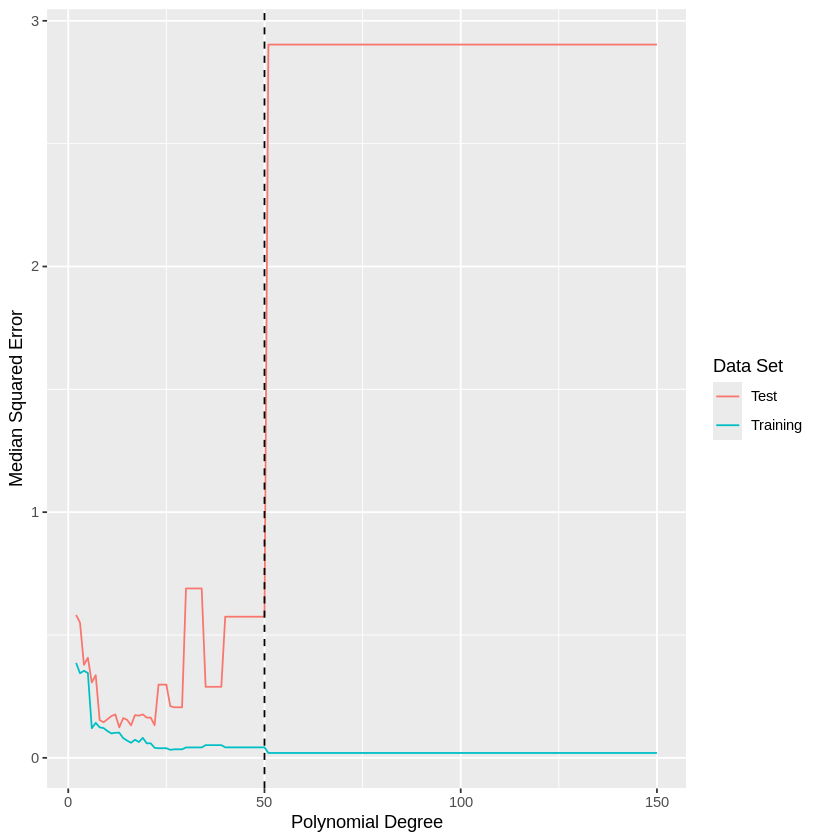

In [72]:
degree = seq(2,150)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    poly.mod <- lm(Y ~ poly(X, k, raw = TRUE), data = dat.train)

    # predict
    train.pred <- predict(poly.mod, newdata = dat.train)
    # squared error
    train.error <- (dat.train$Y - train.pred)^2
    # store rss
    train_rss[k-1] <- median(train.error)

    # test predict
    test.pred <- predict(poly.mod, newdata = dat.test)
    # squared error
    test.error <- (dat.test$Y - test.pred)^2
    # store test rss
    test_rss[k-1] <- median(test.error)
}

results <- data.frame(
    degree = rep(degree, 2),
    rss = c(train_rss, test_rss),
    type = rep(c("Training", "Test"), each = length(degree))
)

# Plot your results here
results |>
  ggplot(aes(x = degree, y = rss, color = type)) +
  geom_line() +
  geom_vline(xintercept = nrow(dat.train), lty = "dashed", col = "black") +
  labs(x = "Polynomial Degree",
       y = "Median Squared Error",
       color = "Data Set")



What do you see as $k$ gets larger than $n$?

> When k exceeds n, the training median squared error drops to approximately zero due to the model having no more data points to constrain it, allowing for perfect interpolation of every point in our training data. However, the test error shoots up and plateaus consistently after k = 50.

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

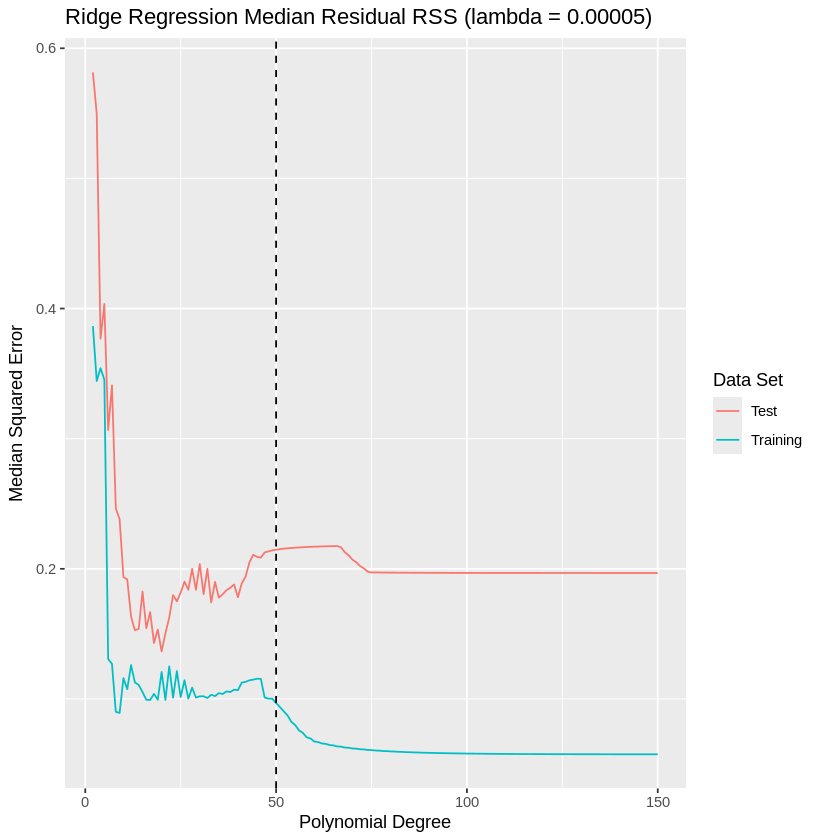

In [73]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    X.poly <- poly(dat.train$X, k, raw = TRUE)
    X.poly.test <- poly(dat.test$X, k, raw = TRUE)
    ridge.mod <- glmnet(X.poly, dat.train$Y, alpha = 0, lambda = lambda)

    # predict
    train.pred <- predict(ridge.mod, newx = X.poly)
    # squared error
    train.error <- (dat.train$Y - train.pred)^2
    # store rss
    train_rss[k-1] <- median(train.error)

    # test predict
    test.pred <- predict(ridge.mod, newx = X.poly.test)
    # squared error
    test.error <- (dat.test$Y - test.pred)^2
    # store test rss
    test_rss[k-1] <- median(test.error)

}

results <- data.frame(
    degree = rep(degree, 2),
    rss = c(train_rss, test_rss),
    type = rep(c("Training", "Test"), each = length(degree))
)

# Plot your results here
results |>
  ggplot(aes(x = degree, y = rss, color = type)) +
  geom_line() +
  geom_vline(xintercept = nrow(dat.train), lty = "dashed", col = "black") +
  labs(title = "Ridge Regression Median Residual RSS (lambda = 0.00005)",
       x = "Polynomial Degree",
       y = "Median Squared Error",
       color = "Data Set")


What happens now when $k$ gets larger than $n$?

> When k exceeds n with ridge regression, the training error no longer immediately drops to zero because the regularization penalty shrinks the coefficients and prevents perfect interpolation of the training data. Furthermore, the test error remains relatively stable instead of the sharp increase we saw prior.
>

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> Regularization penalizes the size of a given model's coefficients, preventing the model from fitting extreme curves that perfectly interpolate the training data when k > n. As such, this added bias from regularization reduces variance much more, keeping test error stable instead of allowing it to dramatically increase due to overfitting.
>

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> *Write your response here*
>

**DUE:** 11:59pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> no